In [8]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.lines import Line2D

sc.set_figure_params(figsize=(5, 5))

In [9]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]

In [10]:
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

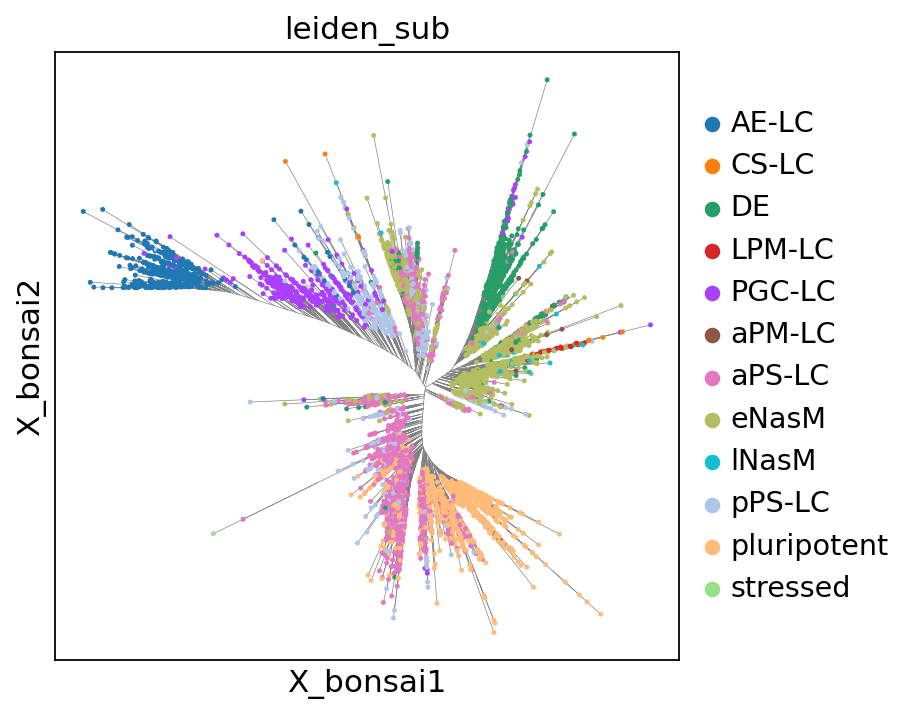

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)
# plt.savefig(
#     "bonsai_micropattern_48h-1_circular_tree_view.png", dpi=300, bbox_inches="tight"
# )

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

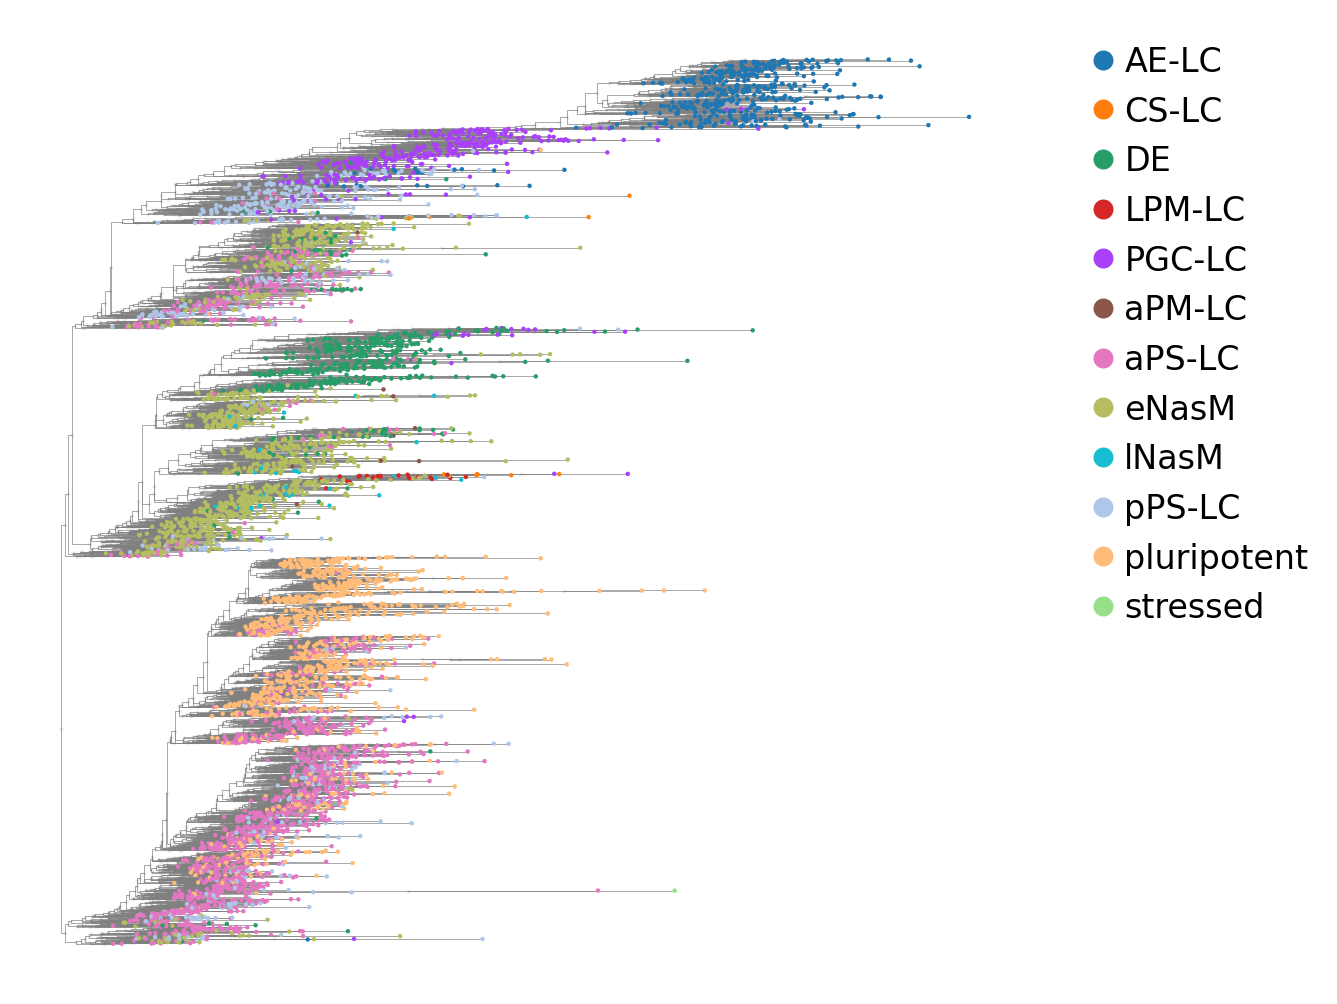

In [12]:
colors = adata.uns["leiden_sub_colors"]
categories = adata.obs["leiden_sub"].cat.categories
cat_to_color = dict(zip(categories, colors))
cell_colors = adata.obs["leiden_sub"].map(cat_to_color).values

coords_d = f["layout_coords/node_coords/ly_dendrogram_ladderized"][:]
edge_coords_d = f["layout_coords/edge_coords/ly_dendrogram_ladderized"][:]

cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(
    coords_d[int_inds, 0], coords_d[int_inds, 1], s=1, c="gray", alpha=0.1, zorder=2
)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")


handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cat_to_color[c],
        markersize=10,
        label=c,
    )
    for c in categories
]
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")
# plt.savefig("bonsai_micropattern_48h-1_rec_tree_view.png", dpi=300, bbox_inches="tight")

In [ ]:
# for web app
# adata.obs.to_csv(
#     "./heemskerk_data/adata_timeseries_old_48h-1_meta.csv", index_label="cellID"
# )

# Optimize tree

In [21]:
from my_tree_layout import Layout_Tree

node_id_to_vert_ind = {}
with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/vertInfo.txt") as f:
    next(f)  # skip header
    for line in f:
        parts = line.strip().split("\t")
        node_id_to_vert_ind[parts[2]] = int(parts[0])

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/tree.nwk") as f:
    nwk_str = f.read().strip()

ly_tree = Layout_Tree()
ly_tree.from_newick(nwk_str, node_id_to_vert_ind=node_id_to_vert_ind)
ly_tree.reset_root(node_id_to_vert_ind["internal_1924"])
ly_tree.equalAngle()
coords = ly_tree.coords.copy()

In [27]:
adata = sc.read_h5ad("./heemskerk_data/adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv("./heemskerk_data/MP_old_48-96h_new_D6-10_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index, :]
f = h5py.File("./heemskerk_data/Bonsai_48h-1/bonsai_vis_data.hdf", "r")
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]
cell_inds = f["tree_info/cell_inds"][:]
int_inds = f["tree_info/int_inds"][:]
metadata = json.loads(f.attrs["metadata_json"])
cell_ids = metadata["cellIds"]
vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])

cell_coords = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]
    else:
        cell_coords[cell_idx] = coords[vert_idx]
adata.obsm["X_bonsai"] = cell_coords

<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

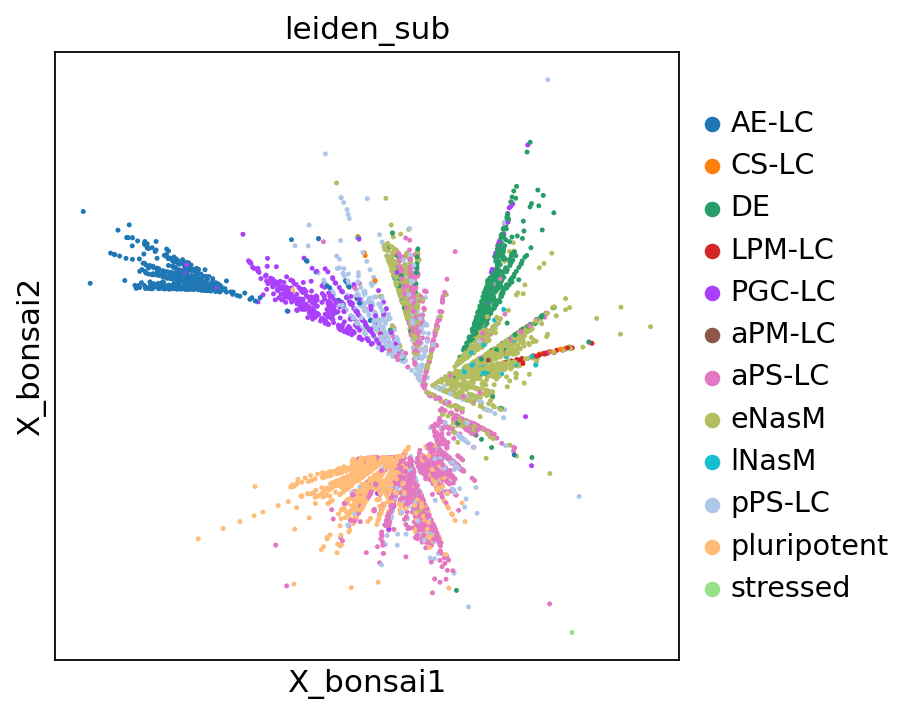

In [29]:
fig, ax = plt.subplots(figsize=(5, 5))
# for e in edge_coords:
#     ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
# optionally plot branch points
# ax.scatter(coords[int_inds, 0], coords[int_inds, 1], s=1, c="gray", alpha=0.5, zorder=2)
sc.pl.embedding(
    adata, basis="X_bonsai", color="leiden_sub", ax=ax, show=False, s=20, zorder=2
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

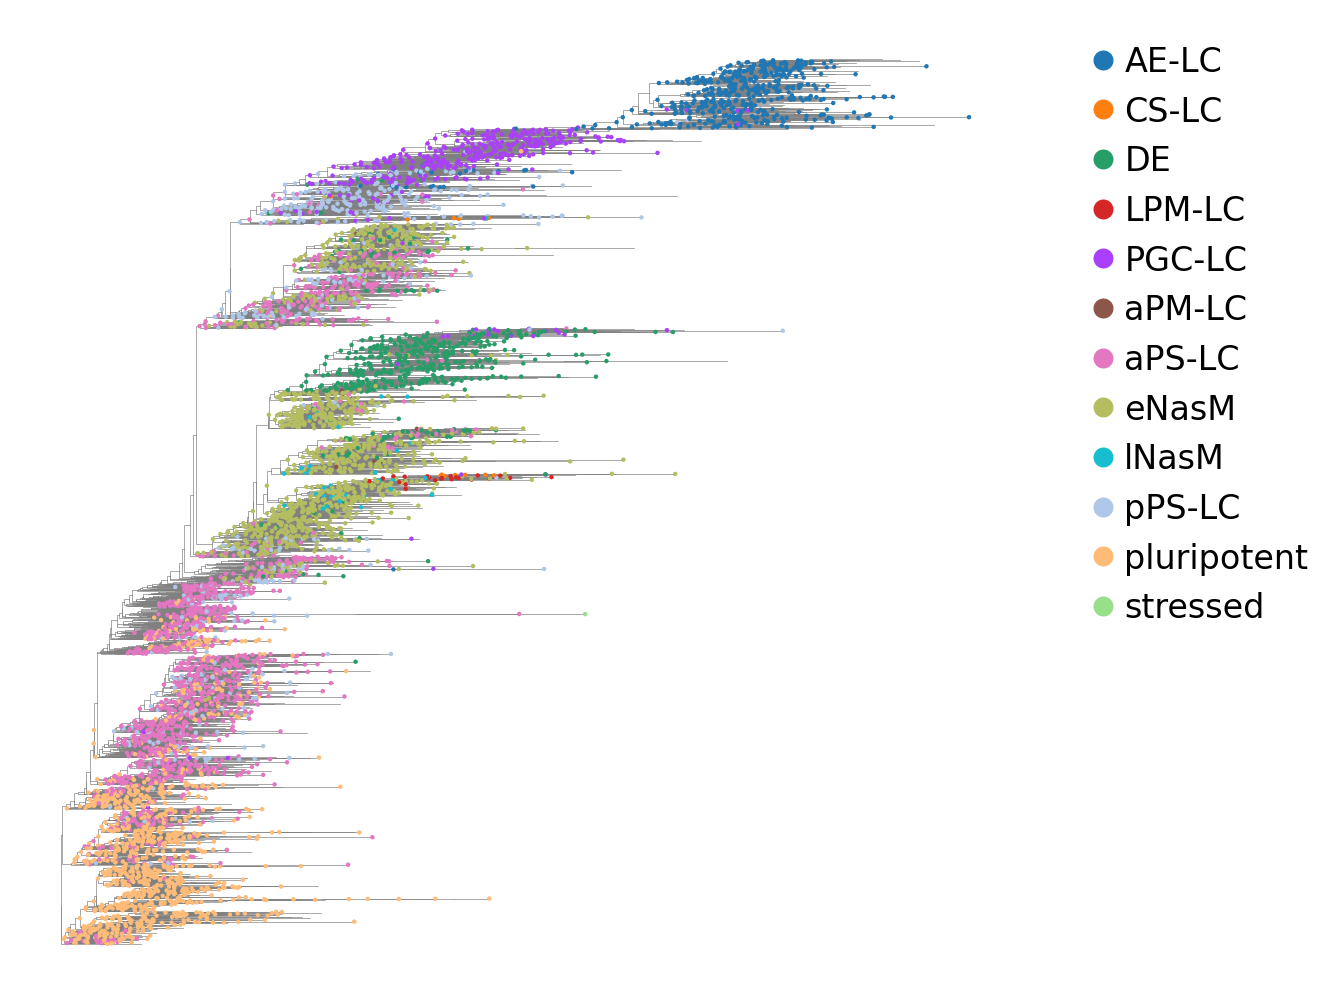

In [31]:
ly_tree.get_dendrogram(ladderized=True)
coords_d = ly_tree.coords.copy()

edge_dict = ly_tree.get_edge_dict(nodeIdToVertInd=node_id_to_vert_ind)
sources = edge_dict["source_ind"]
targets = edge_dict["target_ind"]

# Dendrogram edges: source -> corner -> target (L-shaped)
edge_coords_d = np.zeros((len(sources), 3, 2))
edge_coords_d[:, 0, :] = coords_d[sources]
edge_coords_d[:, 2, :] = coords_d[targets]
edge_coords_d[:, 1, 0] = coords_d[sources, 0]
edge_coords_d[:, 1, 1] = coords_d[targets, 1]

# Map to cells
cell_coords_d = np.zeros((len(cell_ids), 2))
for vert_idx_str, cell_idx in vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords_d[ci] = coords_d[vert_idx]
    else:
        cell_coords_d[cell_idx] = coords_d[vert_idx]

fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors, zorder=3)
ax.set_aspect("auto")
ax.legend(
    handles=handles,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [57]:
import sys

sys.path.insert(0, "/home/stan/Git/micropattern/Bonsai-data-representation")

from downstream_analyses.get_clusters_max_diameter import (
    get_annotation_based_clustering_from_nwk_str,
    get_cluster_assignments,
)

annotation_dict = adata.obs["leiden_sub"].to_dict()

with open("./heemskerk_data/Bonsai_48h-1/final_bonsai_zscore1.0/tree.nwk") as f:
    nwk_str = f.read().strip()
clusters, cut_edges, nmi = get_annotation_based_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, annotation_dict=annotation_dict, cutting_tol=0.005
)
cluster_dict = get_cluster_assignments({"annot": clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

03-18 07:14:41 mp_print INFO Annotation-based clustering has done 2 moves, currently 3 clusters, and Normalized Mutual Information of 0.5168597534963729.
03-18 07:14:41 mp_print INFO Annotation-based clustering has done 4 moves, currently 5 clusters, and Normalized Mutual Information of 0.5906816877586086.
03-18 07:14:41 mp_print INFO 
After making 8 clusters, norm. mutual information doesn't significantly increase. Stopping here.
03-18 07:14:41 mp_print INFO Final annotation-based clustering did 8 moves, created 8 clusters, with a Normalized Mutual Information of 0.6125171516544274.
03-18 07:14:41 mp_print INFO Clustering done


<Axes: title={'center': 'leiden_sub'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

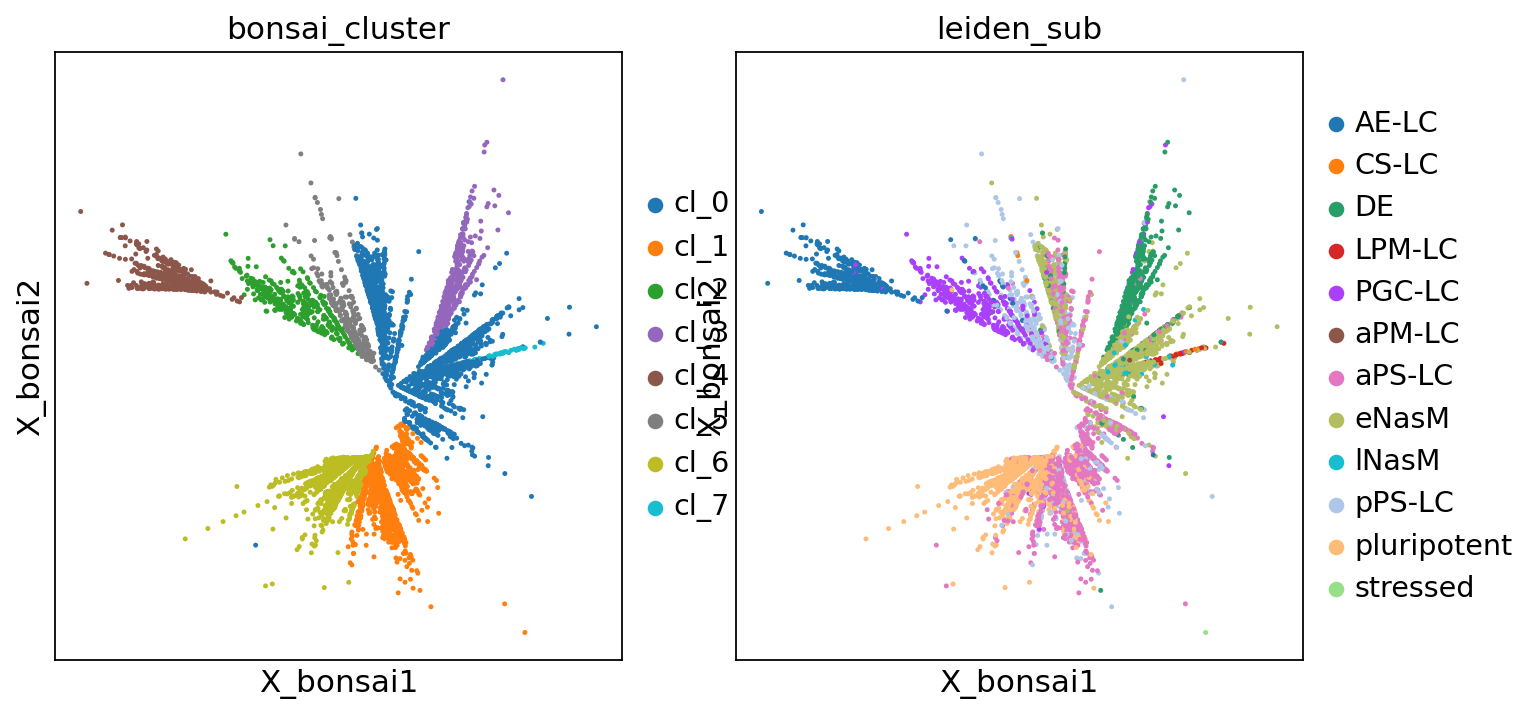

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="bonsai_cluster",
    ax=axes[0],
    show=False,
    s=20,
    palette="tab10",
)
sc.pl.embedding(
    adata,
    basis="X_bonsai",
    color="leiden_sub",
    ax=axes[1],
    show=False,
    s=20,
)

In [67]:
adata.obsm["X_umap"] = adata.obs.loc[
    :, ["umap_old_48-96h_x", "umap_old_48-96h_y"]
].values

<Axes: title={'center': 'leiden_sub'}, xlabel='UMAP1', ylabel='UMAP2'>

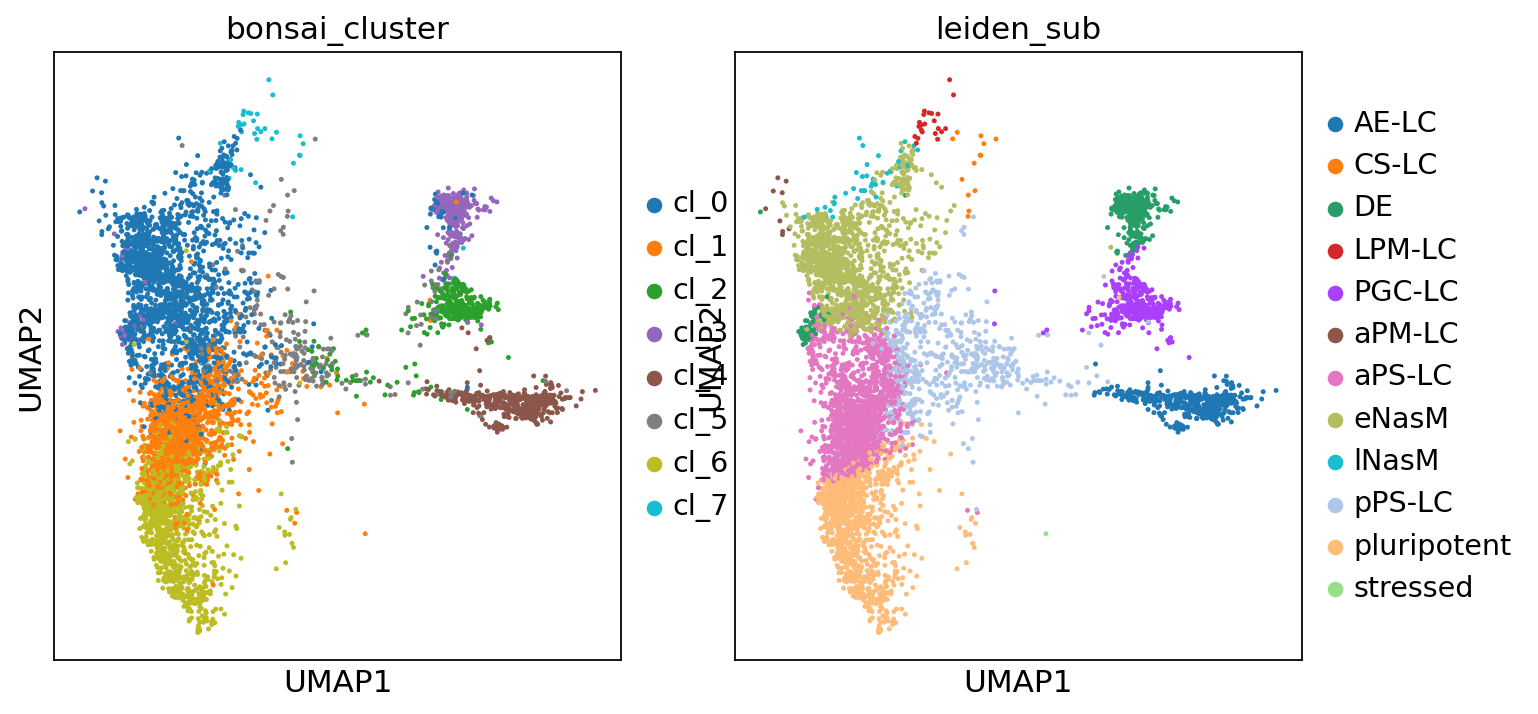

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sc.pl.umap(
    adata,
    color="bonsai_cluster",
    ax=axes[0],
    show=False,
    s=20,
    palette="tab10",
)
sc.pl.umap(
    adata,
    color="leiden_sub",
    ax=axes[1],
    show=False,
    s=20,
)

(np.float64(-1.045), np.float64(1.045), np.float64(-1.045), np.float64(1.045))

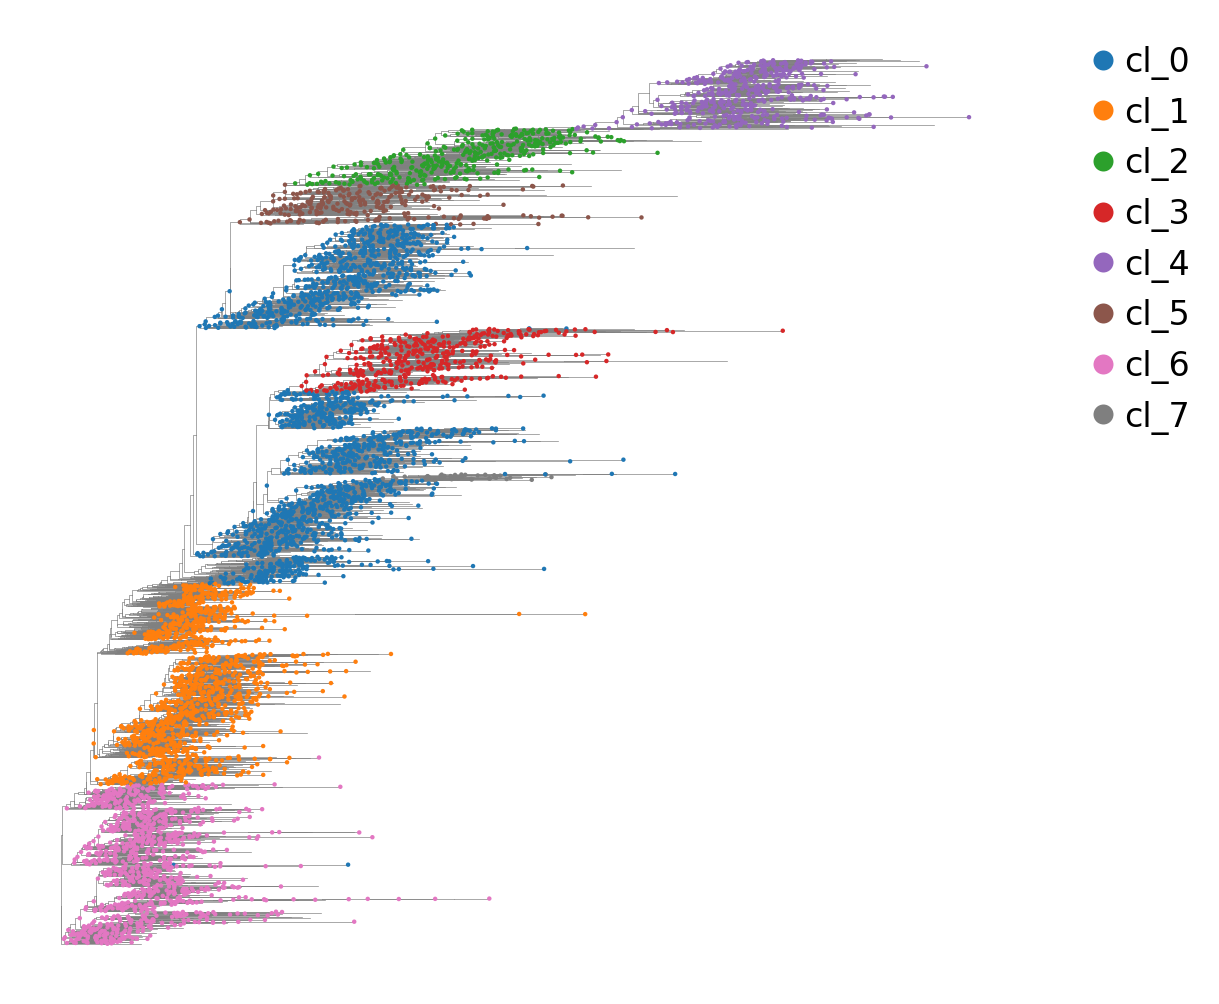

In [63]:
categories_bc = adata.obs["bonsai_cluster"].cat.categories
palette = dict(zip(categories_bc, plt.cm.tab10.colors[: len(categories_bc)]))
cell_colors_bc = [palette[c] for c in adata.obs["bonsai_cluster"]]
fig, ax = plt.subplots(figsize=(8, 8))
for e in edge_coords_d:
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
ax.scatter(cell_coords_d[:, 0], cell_coords_d[:, 1], s=1, c=cell_colors_bc, zorder=3)
ax.set_aspect("auto")
handles_bc = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[c],
        markersize=10,
        label=c,
    )
    for c in categories_bc
]
ax.legend(
    handles=handles_bc,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=False,
    fontsize=15,
)
ax.axis("off")

In [16]:
print(t.children[0].name, t.children[1].name)

internal_1924 internal_1576
